In [ ]:
# Visualization / project imports
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from project_package.data_preprocessing import recipes_functions as rf

# Core libraries
import pandas as pd
import numpy as np
from collections import Counter
from collections import defaultdict
import ast
import re
import os
import glob
from difflib import SequenceMatcher
from sklearn.preprocessing import MinMaxScaler

# Check available functions
print([name for name in dir(rf) if not name.startswith("_")])

['Counter', 'IngredientNormalizer', 'LossyIngredientReducer', 'PROCESSED_DATA_DIR', 'Path', 'SequenceMatcher', 'add_energy_and_who_flags', 'add_fsa_score', 'add_time_minutes', 'app', 'apply_multiple_thresholds', 'clean_c_columns', 'clean_date_column', 'dataset_summary', 'extract_directions', 'fill_na_with_value', 'flatten_nutrition', 'iso_to_minutes', 'kagglehub', 'logger', 'main', 'np', 'os', 'parse_c_vector', 'pd', 're', 'safe_parse', 'save_in_chunks_by_size', 'tqdm', 'typer']


In [25]:
# path setup
file_path = "../data/processed/Recipes"
file_name = "recipes_chunk_"

# find all matching files
files = sorted(glob.glob(os.path.join(file_path, f"{file_name}*.csv")))

# read and combine
df_recipes = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# check
df_recipes.shape


/var/folders/h7/rdkv64ss4rj67v0yrckxlcdc0000gn/T/ipykernel_63556/3453236233.py:9: DtypeWarning: Columns (2,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_recipes = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


(572215, 45)

In [27]:
df_recipes.columns

Index(['RecipeId', 'Name', 'RecipeInstructions', 'Images',
       'AggregatedRating_na', 'ReviewCount', 'Calories', 'FatContent',
       'SaturatedFatContent', 'CholesterolContent', 'SodiumContent',
       'CarbohydrateContent', 'FiberContent', 'SugarContent', 'ProteinContent',
       'source', 'PrepTime', 'CookTime', 'TotalTime', 'PrepTime_Minutes',
       'CookTime_Minutes', 'TotalTime_Minutes', 'RecipeIngredientParts',
       'RecipeIngredientParts_old', 'ingredients_canonical',
       'ingredients_canonical_auto', 'ingredients_canonical_final',
       'ingredients_canonical_final_le_5_replace', 'EnergyFromFat',
       'EnergyFromSaturatedFat', 'EnergyFromCarbs', 'EnergyFromProtein',
       'SaturatedFatPercentEnergy', 'FatPercentEnergy', 'WHO_SatFat_Compliant',
       'WHO_Fat_Compliant', 'WHO_Sodium_Compliant', 'WHO_Score', 'WHO_Healthy',
       'Energy_kJ', 'A_score', 'C_score', 'FSA_Score', 'FSA_Healthy',
       'popularity_score'],
      dtype='object')

## Recipes Dataset Reviews
*Health Distribution of WHO and FSA

In [28]:
summary = {}

# total recipes
df_recipes["ID"]= df_recipes["RecipeId"].astype(str) + "_" + df_recipes["source"].astype(str)

In [29]:
summary = {
    "Total published recipes": df_recipes["ID"].nunique(),

    "Recipes containing nutrition information": df_recipes[
        ["Calories","FatContent","ProteinContent"]
    ].notna().all(axis=1).sum(),

    "Recipes rated/commented": df_recipes["ReviewCount"].gt(0).sum(),

    "Total ratings/comments": df_recipes["ReviewCount"].sum(),

    "Average rating": df_recipes["AggregatedRating_na"].mean(),

    "Average calories": df_recipes["Calories"].mean(),

    "Average prep time (min)": df_recipes["PrepTime_Minutes"].mean(),

    "Average total time (min)": df_recipes["TotalTime_Minutes"].mean()
}

table1 = pd.DataFrame(list(summary.items()), columns=["Metric", "Value"])
table1

,Metric,Value
0,Total published recipes,5.722150e+05
1,Recipes containing nutrition information,5.722150e+05
2,Recipes rated/commented,3.247260e+05
3,Total ratings/comments,5.231852e+06
4,Average rating,2.554383e+00
5,Average calories,4.703383e+02
6,Average prep time (min),5.609672e+01
7,Average total time (min),2.545014e+02


In [30]:
# WHO distribution
who_dist = df_recipes["WHO_Healthy"].value_counts().reset_index()
who_dist.columns = ["WHO_Healthy", "Count"]
who_dist["Percent"] = who_dist["Count"] / who_dist["Count"].sum() * 100

# FSA distribution
fsa_dist = df_recipes["FSA_Healthy"].value_counts().reset_index()
fsa_dist.columns = ["FSA_Healthy", "Count"]
fsa_dist["Percent"] = fsa_dist["Count"] / fsa_dist["Count"].sum() * 100

who_dist, fsa_dist

(   WHO_Healthy   Count    Percent
 0        False  360422  62.987164
 1         True  211793  37.012836,
    FSA_Healthy   Count    Percent
 0        False  412993  72.174445
 1         True  159222  27.825555)

In [31]:
table2 = pd.DataFrame({
    "Category": ["Healthy", "Not Healthy"],
    "WHO_Count": [
        (df_recipes["WHO_Healthy"] == 1).sum(),
        (df_recipes["WHO_Healthy"] == 0).sum()
    ],
    "FSA_Count": [
        (df_recipes["FSA_Healthy"] == 1).sum(),
        (df_recipes["FSA_Healthy"] == 0).sum()
    ]
})

# add percentages
table2["WHO_%"] = table2["WHO_Count"] / table2["WHO_Count"].sum() * 100
table2["FSA_%"] = table2["FSA_Count"] / table2["FSA_Count"].sum() * 100

table2

,Category,WHO_Count,FSA_Count,WHO_%,FSA_%
0,Healthy,211793,159222,37.012836,27.825555
1,Not Healthy,360422,412993,62.987164,72.174445


In [32]:
who_table = (
    df_recipes["WHO_Score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

who_table.columns = ["WHO_Score", "Number_of_Recipes"]

who_table

,WHO_Score,Number_of_Recipes
0,0,113996
1,1,246426
2,2,106737
3,3,105056


In [33]:
fsa_table = (
    df_recipes["FSA_Score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

fsa_table.columns = ["FSA_Score", "Number_of_Recipes"]

fsa_table

,FSA_Score,Number_of_Recipes
0,-9,79
1,-8,491
2,-7,1079
3,-6,2060
4,-5,3574
5,-4,5754
6,-3,8323
7,-2,11731
8,-1,16434
9,0,31082


In [34]:
df_recipes["WHO_binary"] = df_recipes["WHO_Healthy"]
df_recipes["FSA_binary"] = df_recipes["FSA_Healthy"]

df_recipes["FSA_binned"] = pd.cut(
    df_recipes["FSA_Score"],
    bins=[-10, 0, 5, 10, 40],
    labels=[3, 2, 1, 0]  # 3 = healthiest, 0 = least healthy
)
binary_table = pd.DataFrame({
    "Category": ["Healthy", "Not Healthy"],
    "WHO_Count": [
        (df_recipes["WHO_binary"] == 1).sum(),
        (df_recipes["WHO_binary"] == 0).sum()
    ],
    "FSA_Count": [
        (df_recipes["FSA_binary"] == 1).sum(),
        (df_recipes["FSA_binary"] == 0).sum()
    ]
})

# add percentages
binary_table["WHO_%"] = binary_table["WHO_Count"] / binary_table["WHO_Count"].sum() * 100
binary_table["FSA_%"] = binary_table["FSA_Count"] / binary_table["FSA_Count"].sum() * 100

binary_table

,Category,WHO_Count,FSA_Count,WHO_%,FSA_%
0,Healthy,211793,159222,37.012836,27.825555
1,Not Healthy,360422,412993,62.987164,72.174445


## Ingredients Extraction

In [35]:
counter = Counter()

for items in df_recipes["ingredients_canonical_final_le_5_replace"].dropna():
    try:
        # convert string → list
        ingredients = ast.literal_eval(items)

        # count each ingredient separately
        counter.update(ingredients)

    except:
        continue

# convert to dataframe
ingredient_df = pd.DataFrame(
    counter.items(),
    columns=["Ingredient", "Count"]
).sort_values(by="Count", ascending=False)

ingredient_df.head(20)

,Ingredient,Count
19,salt,207585
7,onion,147344
1,sugar,136805
45,butter,135578
8,garlic,131991
26,egg,131107
34,olive oil,97292
28,water,86916
5,milk,73294
51,flour,59313


*#top recipes that contains ingredients with high counts

In [36]:
#top recipes that contains ingredients with high counts
ingredient_ids = defaultdict(set)

for _, row in df_recipes.iterrows():
    recipe_id = row["ID"]
    items = row["ingredients_canonical_final_le_5_replace"]

    try:
        ingredients = ast.literal_eval(items) if isinstance(items, str) else []
        
        for ing in ingredients:
            ingredient_ids[ing].add(recipe_id)

    except:
        continue

In [37]:
ingredient_table = pd.DataFrame({
    "Ingredient": list(ingredient_ids.keys()),
    "Count": [len(v) for v in ingredient_ids.values()],
    "IDs": [list(v)[:10] for v in ingredient_ids.values()]  # show first 10 IDs only
}).sort_values(by="Count", ascending=False)

ingredient_table

,Ingredient,Count,IDs
19,salt,207585,"[142844_foodcom, 24062_foodrecsys, 394850_foodcom, 229210_foodcom, 407965_foodcom, 447463_foodcom, 491546_foodcom, 350053_foodcom, 50580_foodcom, 358245_foodcom]"
7,onion,147344,"[15179_foodcom, 51349_foodcom, 268946_foodcom, 83194_foodcom, 55905_foodcom, 56583_foodcom, 450949_foodcom, 523130_foodcom, 358649_foodcom, 236503_foodrecsys]"
1,sugar,136805,"[107375_foodcom, 51349_foodcom, 167687_foodcom, 18128_foodrecsys, 83998_foodcom, 44246_foodcom, 142844_foodcom, 446019_foodcom, 451241_foodcom, 188518_foodcom]"
45,butter,135578,"[107375_foodcom, 167687_foodcom, 450949_foodcom, 534716_foodcom, 451241_foodcom, 358649_foodcom, 523130_foodcom, 11468_foodrecsys, 491546_foodcom, 422457_foodcom]"
8,garlic,131991,"[360232_foodcom, 234520_foodrecsys, 455484_foodcom, 238675_foodrecsys, 528899_foodcom, 358649_foodcom, 236503_foodrecsys, 62338_foodcom, 298242_foodcom, 511383_foodcom]"
...,...,...,...
4183,torn arugula leaf,6,"[84726_foodrecsys, 57955_foodrecsys, 81026_foodrecsys, 231871_foodrecsys, 241562_foodrecsys, 14343_foodrecsys]"
429,olive oil flavored vegetable cooking spray,6,"[325_foodcom, 180651_foodcom, 296082_foodcom, 29975_foodcom, 3529_foodcom, 414821_foodcom]"
4181,mccormick garlic powder,6,"[235413_foodrecsys, 219118_foodrecsys, 241571_foodrecsys, 255337_foodrecsys, 241572_foodrecsys, 255977_foodrecsys]"
4172,fluid ounce whiskey,6,"[229196_foodrecsys, 241405_foodrecsys, 244119_foodrecsys, 153120_foodrecsys, 46815_foodrecsys, 256262_foodrecsys]"


In [38]:
from collections import Counter
import ast

counter = Counter()

for items in df_recipes["ingredients_canonical_final_le_5_replace"].dropna():
    try:
        ingredients = ast.literal_eval(items)
        counter.update(ingredients)
    except:
        continue

top200 = set([i[0] for i in counter.most_common(200)])

In [39]:
recipe_counts = []

for _, row in df_recipes.iterrows():
    recipe_id = row["ID"]
    
    try:
        ingredients = set(ast.literal_eval(row["ingredients_canonical_final_le_5_replace"]))
        count = len(ingredients & top200)
        
        recipe_counts.append({
            "ID": recipe_id,
            "Name": row["Name"],
            "Top200_Ingredient_Count": count,
            "URL": row["Images"], 
            "FSA_Healthy": row["FSA_Healthy"], 
            "WHO_Healthy": row["WHO_Healthy"], 
            "popularity": row["popularity_score"]
        })
        
    except:
        continue

In [40]:
recipe_df = pd.DataFrame(recipe_counts)

## Cluster Analysis

Shape after trimming: (539351, 49)


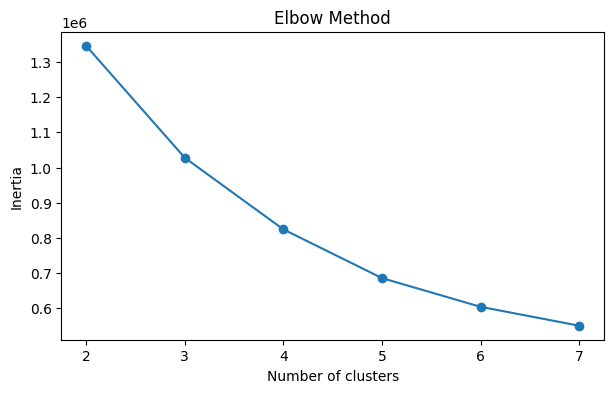

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df_cluster = df_recipes.copy()

cluster_features = [
    "Calories",
    "FatContent",
    "SugarContent",
    "ProteinContent"
]

# keep usable rows
df_cluster = df_cluster.dropna(subset=cluster_features).copy()

# keep nonnegative values
for col in cluster_features:
    df_cluster = df_cluster[df_cluster[col] >= 0]

#remove extreme outliers
#    keep middle 1% to 99%

for col in cluster_features:
    lower = df_cluster[col].quantile(0.01)
    upper = df_cluster[col].quantile(0.99)
    df_cluster = df_cluster[(df_cluster[col] >= lower) & (df_cluster[col] <= upper)]

print("Shape after trimming:", df_cluster.shape)

# popularity log
df_cluster["popularity_log"] = np.log1p(df_cluster["popularity_score"].fillna(0))

X = df_cluster[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  elbow method
inertia = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [42]:
# run clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

print(df_cluster["cluster"].value_counts().sort_index())

cluster
0    306445
1    156805
2     36691
3     39410
Name: count, dtype: int64


In [43]:
## add center points 

centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
)

print(centers.round(2))

   Calories  FatContent  SugarContent  ProteinContent
0    203.11        9.00         10.61            5.78
1    470.17       23.96          7.16           27.37
2    723.26       31.12         71.95           10.31
3   1013.05       62.43         12.92           43.25


* PCA plot

In [44]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_cluster["pca1"] = X_pca[:, 0]
df_cluster["pca2"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.5975015  0.27156968]


In [45]:
print(df_cluster[["pca1", "pca2", "cluster"]].head())

       pca1      pca2  cluster
0 -1.114861  1.032642        0
1  4.336520 -1.123647        3
2 -0.458090  3.140693        2
3  1.138895  0.348479        1
4 -1.425289  0.459053        0


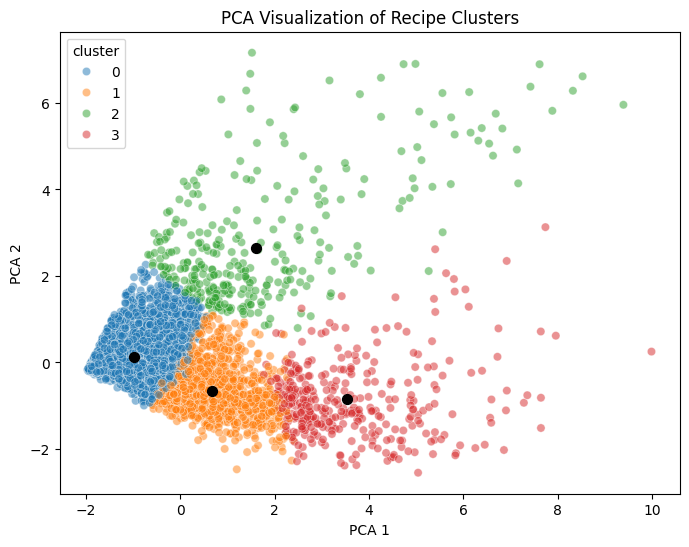

In [46]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_cluster.sample(min(5000, len(df_cluster)), random_state=42),
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="tab10",
    alpha=0.5
)

centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    color="black",
    s=50,
    marker="o"
)

plt.title("PCA Visualization of Recipe Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()




In [47]:
cluster_summary = df_cluster.groupby("cluster").agg(
    recipe_count=("RecipeId", "count"),
    avg_calories=("Calories", "mean"),
    avg_fat=("FatContent", "mean"),
    avg_sugar=("SugarContent", "mean"),
    avg_protein=("ProteinContent", "mean"),
    avg_fsa=("FSA_Score", "mean"),
    avg_who=("WHO_Score", "mean"),
    pct_who_healthy=("WHO_Healthy", "mean"),
    pct_fsa_healthy=("FSA_Healthy", "mean"),
    avg_popularity=("popularity_score", "mean"),
    median_popularity=("popularity_score", "median")
).round(2)

cluster_summary

,recipe_count,avg_calories,avg_fat,avg_sugar,avg_protein,avg_fsa,avg_who,pct_who_healthy,pct_fsa_healthy,avg_popularity,median_popularity
cluster,,,,,,,,,,,
0,306445,203.11,9.01,10.60,5.78,5.25,1.69,0.48,0.44,43.45,4.0
1,156805,470.35,23.97,7.16,27.39,12.19,0.95,0.24,0.10,49.84,4.0
2,36691,721.97,31.07,71.85,10.29,22.24,1.38,0.34,0.00,31.53,3.0
3,39410,1013.84,62.47,12.96,43.24,21.34,0.47,0.08,0.00,24.16,4.0


## # analyze ingredients per cluster

In [ ]:
# analyze ingredients per cluster
def parse_ingredients(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return parsed
        except:
            pass
    return []

df_cluster["ingredients_final_list"] = df_cluster[
    "ingredients_canonical_final_le_5_replace"
].apply(parse_ingredients)


df_ing = df_cluster[["ID", "cluster", "ingredients_final_list"]].copy()

df_ing = df_ing.explode("ingredients_final_list")

df_ing = df_ing.rename(columns={"ingredients_final_list": "ingredient"})

df_ing["ingredient"] = (
    df_ing["ingredient"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df_ing = df_ing[
    (df_ing["ingredient"] != "") &
    (df_ing["ingredient"] != "[]") &
    (df_ing["ingredient"] != "nan")
]


stop_ingredients = [
    "salt", "water", "pepper"
]

df_ing = df_ing[~df_ing["ingredient"].isin(stop_ingredients)]



top_ing_per_cluster = (
    df_ing.groupby(["cluster", "ingredient"])
    .size()
    .reset_index(name="count")
)


top10_ing = (
    top_ing_per_cluster
    .sort_values(["cluster", "count"], ascending=[True, False])
    .groupby("cluster")
    .head(10)
)

top10_ing

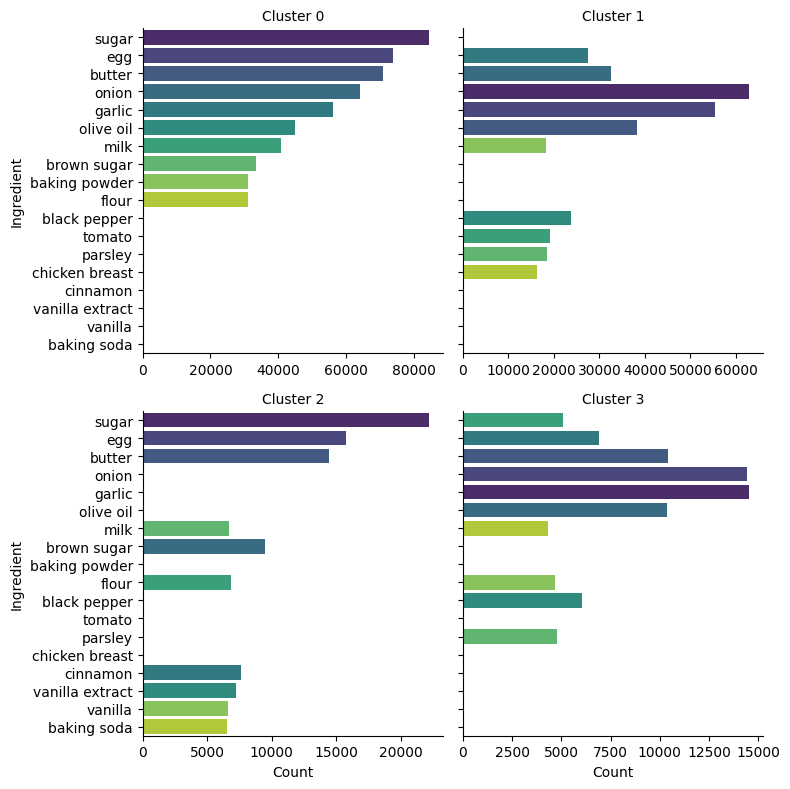

In [ ]:
g = sns.FacetGrid(top10_ing, col="cluster", col_wrap=2, sharex=False, height=4)

g.map_dataframe(
    sns.barplot,
    x="count",
    y="ingredient",
    hue="ingredient",
    dodge=False,
    palette="viridis"
)

g.set_titles("Cluster {col_name}")
g.set_axis_labels("Count", "Ingredient")

for ax in g.axes.flatten():
    if ax is not None:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

plt.tight_layout()
plt.show()

In [ ]:
representative_recipes = (
    df_cluster.sort_values(["cluster", "popularity_score"], ascending=[True, False])
    .groupby("cluster")
    .head(5)[[
        "cluster", "ID", "Name", "Calories", "FatContent", "SugarContent",
        "ProteinContent", "FSA_Score", "WHO_Score", "popularity_score"
    ]]
)

representative_recipes

,cluster,ID,Name,Calories,FatContent,SugarContent,ProteinContent,FSA_Score,WHO_Score,popularity_score
553356,0,162760_foodrecsys,Fluffy Pancakes,230.3520,8.208835,8.570360,6.370725,11,1,47971.394739
523579,0,56927_foodrecsys,Delicious Ham and Potato Soup,194.8774,10.504740,3.778497,6.083965,8,1,47548.369605
554088,0,17652_foodrecsys,Banana Crumb Muffins,263.2594,8.102324,26.530080,3.199475,13,2,46973.898019
554015,0,20144_foodrecsys,Banana Banana Bread,228.9412,8.848529,14.269150,3.768562,9,1,45916.931489
554152,0,21014_foodrecsys,Good Old Fashioned Pancakes,158.3263,5.921107,3.459945,4.510731,7,1,44390.695049
530084,1,23600_foodrecsys,World's Best Lasagna,448.2073,21.341340,8.601563,29.665170,16,0,53575.129114
535710,1,26317_foodrecsys,Chicken Pot Pie IX,415.2506,24.020090,3.402760,18.658000,14,0,38748.427032
554381,1,50644_foodrecsys,Broiled Tilapia Parmesan,224.3816,12.823910,0.208247,25.371230,4,1,33107.971449
528306,1,16066_foodrecsys,Awesome Slow Cooker Pot Roast,425.7317,23.683520,0.851270,45.631060,15,1,31937.971874
534991,1,8941_foodrecsys,Slow Cooker Chicken and Dumplings,384.6235,18.030630,6.176880,18.105270,15,0,29247.035877


## Cluster heatmap

In [ ]:
heatmap_df = df_cluster.groupby("cluster")[[
    "Calories",
    "FatContent",
    "SugarContent",
    "ProteinContent",
    "FSA_Score",
    "WHO_Score"
]].mean()

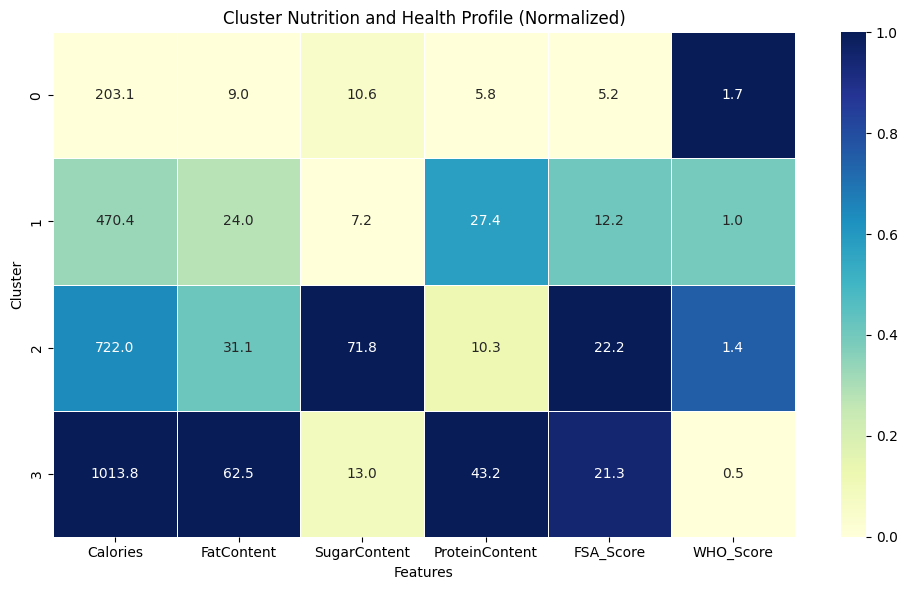

In [ ]:


plt.clf()
plt.close('all')
scaler = MinMaxScaler()

plt.figure(figsize=(10, 6))

heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_df),
    index=heatmap_df.index,
    columns=heatmap_df.columns
)
sns.heatmap(
    heatmap_scaled,
    annot=heatmap_df.round(1),
    fmt="",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Cluster Nutrition and Health Profile (Normalized)")
plt.xlabel("Features")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()